# Employee Spending Analysis & Savings Prediction
This notebook demonstrates a full data science pipeline:
- Preprocessing
- Standardization
- PCA
- Model Building (Random Forest)
- Evaluation
- Prediction
- Visualization (Matplotlib & Seaborn)
- Confusion Matrix example
- Preparation for Streamlit dashboard


In [8]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib plotly


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import joblib

%matplotlib inline
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv(r"C:\Users\antor\Downloads\financial_data.csv");
df['Desired_Savings'] = df['Income'] - (
    df['Rent'] + df['Groceries'] + df['Transport'] + df['Eating_Out'] +
    df['Entertainment'] + df['Utilities'] + df['Healthcare'] +
    df['Education'] + df['Miscellaneous']
)

df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49.0,0.0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,13472.117836,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34.0,2.0,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,10546.341350,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35.0,1.0,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,20705.354061,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21.0,0.0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,43316.813128,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52.0,4.0,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,10014.217101,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


## Dataset Information

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20600 entries, 0 to 20599
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           19558 non-null  float64
 1   Age                              19570 non-null  float64
 2   Dependents                       19558 non-null  float64
 3   Occupation                       19578 non-null  object 
 4   City_Tier                        19579 non-null  object 
 5   Rent                             19558 non-null  float64
 6   Loan_Repayment                   20600 non-null  float64
 7   Insurance                        20600 non-null  float64
 8   Groceries                        20600 non-null  float64
 9   Transport                        20600 non-null  float64
 10  Eating_Out                       20600 non-null  float64
 11  Entertainment                    20600 non-null  float64
 12  Utilities         

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,1.955800e+04,19570.000000,19558.000000,19558.000000,20600.000000,20600.000000,20600.000000,20600.000000,20600.000000,20600.000000,...,1.955800e+04,20600.000000,20600.000000,20600.000000,20600.000000,20600.000000,20600.000000,20600.000000,20600.000000,20600.000000
mean,4.557977e+04,40.545171,2.000460,9100.519313,2050.008769,1455.143741,5207.009773,2703.885240,1462.214706,1448.372665,...,1.820124e+04,10637.816798,911.401407,472.569494,255.225933,253.519732,436.065009,41.581510,62.384134,144.682273
std,7.610599e+04,14.292411,1.417626,9250.093587,4277.944883,1492.155109,5047.885780,2667.165551,1484.848403,1488.677475,...,6.401703e+04,11719.057982,1036.025870,536.405331,297.900471,299.071250,503.532955,53.126138,98.410183,168.702821
min,1.371763e+03,-5.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,2.609590e+02,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.772019e+04,29.000000,1.000000,3649.766296,0.000000,580.353104,2162.714932,1124.092522,579.895161,581.068497,...,5.806918e+03,3772.264252,317.149714,161.955928,84.581746,84.711848,147.918509,11.038737,4.945589,47.591560
50%,3.037797e+04,41.000000,2.000000,6396.039417,0.000000,1015.974487,3739.738974,1930.659780,1027.844291,1019.447997,...,1.011956e+04,7221.029820,606.414730,306.411888,164.927660,164.500853,285.458917,25.241848,33.190591,92.840425
75%,5.255819e+04,53.000000,3.000000,11238.498794,2626.016257,1788.197908,6472.388831,3360.517582,1810.112041,1789.065162,...,1.777722e+04,13318.508194,1126.214650,587.601816,313.363567,310.313357,538.983703,52.401163,81.010354,178.229594
max,3.619570e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,3.414333e+06,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137


## Preprocessing

In [5]:
print(df.isnull().sum())
df.fillna(df.median(numeric_only=True), inplace=True)

Income                             1042
Age                                1030
Dependents                         1042
Occupation                         1022
City_Tier                          1021
Rent                               1042
Loan_Repayment                        0
Insurance                             0
Groceries                             0
Transport                             0
Eating_Out                            0
Entertainment                         0
Utilities                             0
Healthcare                            0
Education                             0
Miscellaneous                         0
Desired_Savings_Percentage            0
Desired_Savings                    1042
Disposable_Income                     0
Potential_Savings_Groceries           0
Potential_Savings_Transport           0
Potential_Savings_Eating_Out          0
Potential_Savings_Entertainment       0
Potential_Savings_Utilities           0
Potential_Savings_Healthcare          0


## Feature Selection

In [6]:
X = df.drop('Desired_Savings', axis=1)
y = df['Desired_Savings']

## Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Convert categorical features
df = pd.get_dummies(df, drop_first=True)

# Features and target
X = df[['Income','Age','Dependents','Rent','Groceries','Transport',
        'Eating_Out','Entertainment','Utilities','Healthcare',
        'Education','Miscellaneous']]
y = df["Desired_Savings"]

# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Standardization

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA (Dimensionality Reduction)

In [26]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Number of components:', pca.n_components_)

Number of components: 6


## Model Building

In [27]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train_pca, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction

In [28]:
y_pred = model.predict(X_test_pca)
y_pred[:5]

array([21937.22973478, 29249.98404416, 10579.78095158, 31092.91873275,
       11883.70362565])

## Evaluation

In [29]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R2 Score:', r2)

RMSE: 7936.55852110294
R2 Score: 0.9770237818096995


## Visualization: Spending Distribution

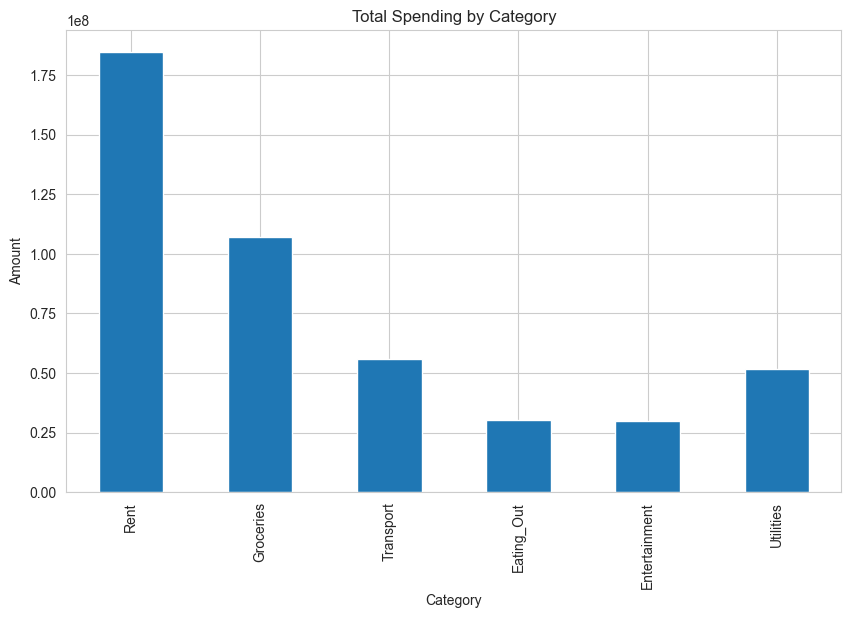

In [30]:
spending_cols = ['Rent','Groceries','Transport','Eating_Out','Entertainment','Utilities']

df[spending_cols].sum().plot(kind='bar', figsize=(10,6))

plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Amount')

plt.show()

## Correlation Heatmap

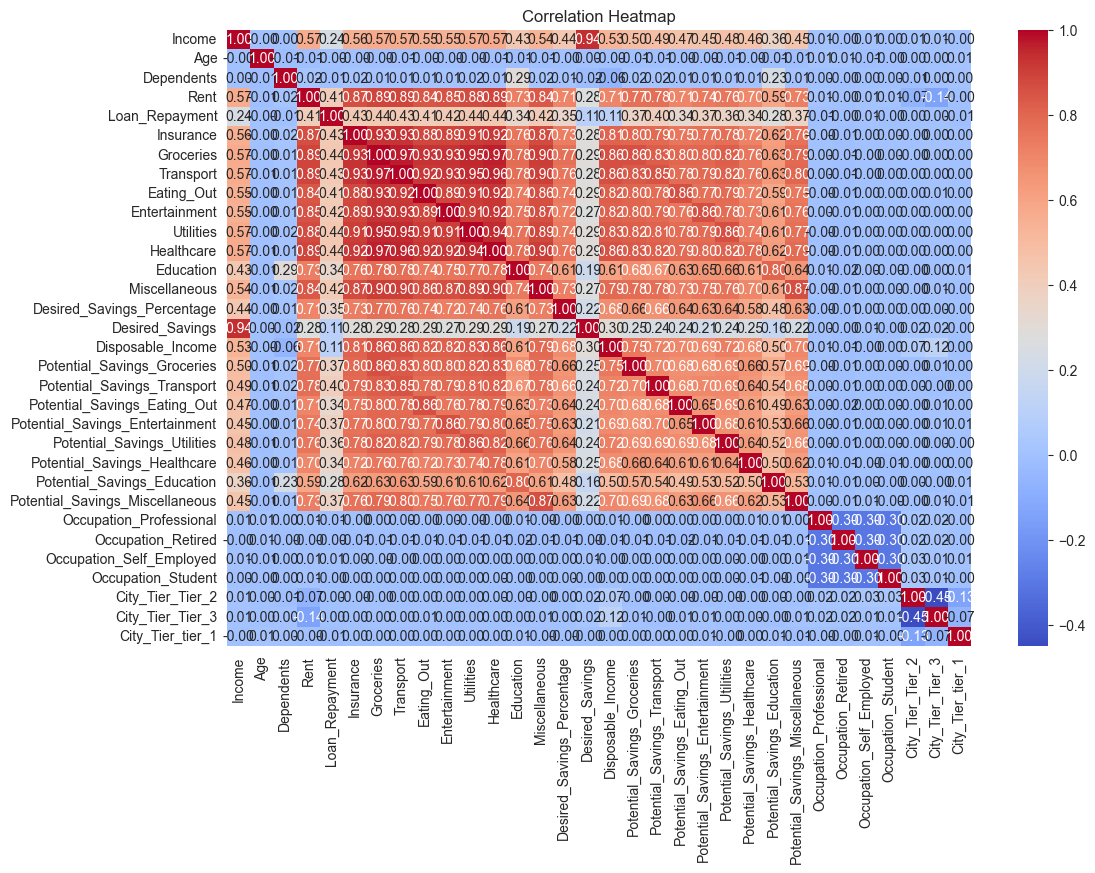

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

## Actual vs Predicted Plot

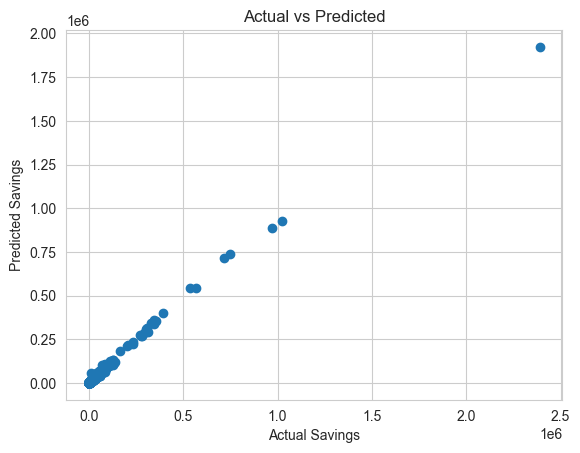

In [32]:
plt.scatter(y_test, y_pred)

plt.xlabel('Actual Savings')
plt.ylabel('Predicted Savings')
plt.title('Actual vs Predicted')

plt.show()

## Residual Plot

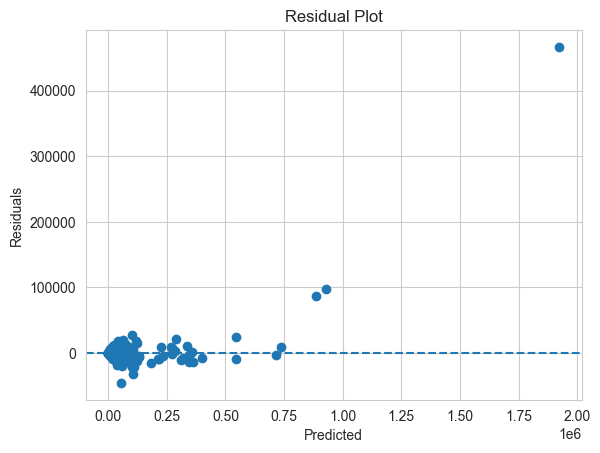

In [33]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

## Save Model for Streamlit

In [34]:
joblib.dump(model,'savings_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(pca,'pca.pkl')
joblib.dump(X.columns, "model_features.pkl")
print('Model files saved successfully')

Model files saved successfully
